# Simple Logistic Regression Workbench

This notebook creates a capped dataset from `obs100000LP.csv`, keeping every `(level_t, learn_cnt)` combination that occurs more than 1,000 times and randomly retaining 1,000 observations for each qualifying combination.

The capped dataset is then used for the existing 66/33 stratified train/test logistic-regression workflow. The validation section reports `level_t`, `learn_cnt`, number of appearances, empirical success rate, and model success rate for every combination present in the validation set.


## 1. Imports

Only the small set of packages needed for loading data, training the model, and reporting results are imported here.

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Any

import pandas as pd
from IPython.display import display
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator
import numpy as np
from sklearn.model_selection import StratifiedKFold

## 2. Configuration

The train/test split is fixed at 66/33. The model uses `level_t` and `learn_cnt`. The notebook first creates `obs100000LP_capped1000.csv` from `obs100000LP.csv` and then trains the model on the capped dataset.


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "output").exists():
            return candidate
        if (candidate / "python" / "output").exists():
            return candidate / "python"
    raise FileNotFoundError("Could not find the python/output folder.")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "output"

CAPPED_LIMIT = 1000

SOURCE_DATASET_NAME = "obs100000LP"
CAPPED_DATASET_NAME = "obs100000LP_capped1000"
# CAPPED_DATASET_NAME = "obs100000LP_capped2000"
# CAPPED_DATASET_NAME = "obs100000LP_capped4000"

# SOURCE_DATASET_NAME = "obs100000MP"
# CAPPED_DATASET_NAME = "obs100000MP_capped1000"
# CAPPED_DATASET_NAME = "obs100000MP_capped2000"
# CAPPED_DATASET_NAME = "obs100000MP_capped4000"

TARGET_COLUMN = "a_t"
BASE_FEATURE_COLUMNS = ["level_t", "learn_cnt"]
OPTIONAL_LAG_FEATURE_COLUMNS = ["a_t_minus_5", "a_t_minus_4", "a_t_minus_3", "a_t_minus_2", "a_t_minus_1"]
    
USE_LAG_FEATURES = False
FEATURE_COLUMNS = BASE_FEATURE_COLUMNS + OPTIONAL_LAG_FEATURE_COLUMNS if USE_LAG_FEATURES else BASE_FEATURE_COLUMNS

RANDOM_SEED = 42
TEST_SIZE = 0.33

print(f"Project root: {PROJECT_ROOT}")
print(f"Source dataset: {SOURCE_DATASET_NAME}.csv")
print(f"Capped dataset: {CAPPED_DATASET_NAME}.csv")


Project root: C:\Users\valdr\source\repos\DissertationRepo\python
Source dataset: obs100000LP.csv
Capped dataset: obs100000LP_capped1000.csv


## 3. Data Loading and Capping

The source CSV is loaded first. Every `(level_t, learn_cnt)` combination is counted. Only combinations occurring strictly more than 1,000 times are retained, and exactly 1,000 observations are randomly sampled from each qualifying combination using the fixed random seed. The resulting dataset is saved as `obs100000LP_capped1000.csv` or `obs100000MP_capped1000.csv` depending on the source dataset used.


In [3]:
def load_dataset(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
    missing_columns = [column for column in required_columns if column not in frame.columns]
    if missing_columns:
        raise ValueError(f"Missing columns in {csv_path.name}: {', '.join(missing_columns)}")
    return frame[required_columns].sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)


source_path = DATA_DIR / f"{SOURCE_DATASET_NAME}.csv"
if not source_path.exists():
    raise FileNotFoundError(f"Could not find source dataset: {source_path}")

source_frame = pd.read_csv(source_path)
required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in source_frame.columns]
if missing_columns:
    raise ValueError(f"Missing columns in {source_path.name}: {', '.join(missing_columns)}")

# Count every level_t / learn_cnt combination.
combination_counts = (
    source_frame
    .groupby(["level_t", "learn_cnt"], dropna=False)
    .size()
    .reset_index(name="combination_count")
)

# Keep only combinations occurring MORE THAN 1000 times.
qualifying_combinations = combination_counts.loc[
    combination_counts["combination_count"] > CAPPED_LIMIT,
    ["level_t", "learn_cnt"]
]

print(f"Found {len(qualifying_combinations)} combinations occurring more than {CAPPED_LIMIT} times.")

# Keep observations belonging to qualifying combinations.
capped_frame = source_frame.merge(
    qualifying_combinations,
    on=["level_t", "learn_cnt"],
    how="inner",
)[required_columns]

# Randomly retain exactly 1000 observations per qualifying combination.
capped_frame = (
    capped_frame
    .groupby(["level_t", "learn_cnt"], group_keys=False)
    .sample(n=CAPPED_LIMIT, random_state=RANDOM_SEED)
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)

capped_path = DATA_DIR / f"{CAPPED_DATASET_NAME}.csv"
capped_frame.to_csv(capped_path, index=False)

print(f"Created {CAPPED_DATASET_NAME}.csv with {len(capped_frame):,} rows.")
display(capped_frame.head())

# The model is deliberately trained only on the newly created capped dataset.
datasets = {
    CAPPED_DATASET_NAME: load_dataset(capped_path)
}

for name, frame in datasets.items():
    print(f"{name}: {frame.shape[0]:,} rows x {frame.shape[1]} columns")


Found 29 combinations occurring more than 1000 times.
Created obs100000LP_capped1000.csv with 29,000 rows.


,level_t,learn_cnt,a_t
0,1,0,0
1,1,0,0
2,1,0,1
3,1,0,0
4,1,0,1


obs100000LP_capped1000: 29,000 rows x 3 columns


## 4. Model Training

A single pipeline is used for the capped dataset: median imputation, standardisation, and logistic regression. The split is 67% training and 33% validation, corresponding to the desired 66/33 split using `TEST_SIZE = 0.33`.


In [4]:
class PerLevelLogisticRegression:
    """Wraps one LogisticRegression per level behind a single predict/predict_proba
    interface -- drop-in replacement anywhere the notebook expects a single model.
    """

    def __init__(self, per_level_models: dict):
        self.per_level_models = per_level_models
        self.classes_ = np.array([0, 1])

    def predict_proba(self, X: pd.DataFrame) -> np.ndarray:
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X, columns=["level_t", "learn_cnt"])

        proba_class1 = np.zeros(len(X))

        for level, sub_model in self.per_level_models.items():
            mask = (X["level_t"] == level).values

            if mask.any():
                proba_class1[mask] = sub_model.predict_proba(
                    X.loc[mask, ["learn_cnt"]]
                )[:, 1]

        return np.column_stack([1 - proba_class1, proba_class1])

    def predict(self, X: pd.DataFrame) -> np.ndarray:
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)


def calculate_metrics(y_true, y_pred) -> dict[str, Any]:
    """Calculate classification metrics including the confusion matrix."""

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1]
    ).ravel()

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),
        "specificity": (
            tn / (tn + fp)
            if (tn + fp)
            else 0.0
        ),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def train_and_evaluate(frame: pd.DataFrame) -> dict[str, Any]:

    # ---------------------------------------------------------
    # Train/test split
    # ---------------------------------------------------------
    X_train, X_test, y_train, y_test = train_test_split(
        frame[FEATURE_COLUMNS],
        frame[TARGET_COLUMN],
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=(
            frame[TARGET_COLUMN]
            if frame[TARGET_COLUMN].nunique() > 1
            else None
        ),
    )

    # ---------------------------------------------------------
    # Train one logistic regression model per level
    # ---------------------------------------------------------
    per_level_models = {}

    for level in sorted(X_train["level_t"].unique()):

        mask = X_train["level_t"] == level

        per_level_models[level] = LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_SEED
        ).fit(
            X_train.loc[mask, ["learn_cnt"]],
            y_train[mask]
        )

    # ---------------------------------------------------------
    # Combined model wrapper
    # ---------------------------------------------------------
    model = PerLevelLogisticRegression(per_level_models)

    # Predictions for the complete validation set
    y_pred = model.predict(X_test)

    # ---------------------------------------------------------
    # Combined metrics
    # ---------------------------------------------------------
    combined_metrics = calculate_metrics(
        y_test,
        y_pred
    )

    # ---------------------------------------------------------
    # Per-level metrics
    # ---------------------------------------------------------
    level_metrics = {}

    for level in sorted(X_test["level_t"].unique()):

        mask = X_test["level_t"] == level

        level_y_test = y_test.loc[mask]
        level_y_pred = y_pred[mask.values]

        level_metrics[level] = {
            "rows": int(mask.sum()),
            **calculate_metrics(
                level_y_test,
                level_y_pred
            )
        }

    return {
        "model": model,
        "X_test": X_test.reset_index(drop=True),
        "y_test": y_test.reset_index(drop=True),
        "y_pred": pd.Series(y_pred).reset_index(drop=True),

        # Combined metrics
        "metrics": combined_metrics,

        # Metrics broken down by level
        "level_metrics": level_metrics,
    }


def summarize_result(
    dataset_name: str,
    frame: pd.DataFrame
) -> tuple[dict[str, Any], list[dict[str, Any]]]:

    result = train_and_evaluate(frame)

    rows = []

    # ---------------------------------------------------------
    # Per-level results
    # ---------------------------------------------------------
    for level, metrics in result["level_metrics"].items():

        rows.append({
            "dataset": dataset_name,
            "level": level,
            **metrics,
        })

    # ---------------------------------------------------------
    # Combined result
    # ---------------------------------------------------------
    rows.append({
        "dataset": dataset_name,
        "level": "Combined",
        "rows": len(result["X_test"]),
        **result["metrics"],
    })

    return result, rows


# =============================================================
# Train and evaluate all datasets
# =============================================================

training_results = {}
results_rows = []

for dataset_name, frame in datasets.items():

    result, summary_rows = summarize_result(
        dataset_name,
        frame
    )

    training_results[dataset_name] = result
    results_rows.extend(summary_rows)


# =============================================================
# Final results table
# =============================================================

results_df = (
    pd.DataFrame(results_rows)
    .sort_values(
        ["dataset", "level"],
        key=lambda s: (
            s.map({
                "Combined": 99
            }).fillna(s)
            if s.name == "level"
            else s
        )
    )
    .reset_index(drop=True)
)

display(results_df)


,dataset,level,rows,accuracy,precision,recall,f1_score,specificity,tn,fp,fn,tp
0,obs100000LP_capped1000,1,2029,0.651060,0.651060,1.000000,0.788657,0.000000,0,708,0,1321
1,obs100000LP_capped1000,2,3258,0.575506,0.567077,0.933521,0.705557,0.146999,218,1265,118,1657
2,obs100000LP_capped1000,3,4283,0.517861,0.511381,0.321718,0.394960,0.705667,1544,644,1421,674
3,obs100000LP_capped1000,Combined,9570,0.565726,0.582549,0.703525,0.637347,0.402375,1762,2617,1539,3652


### Tri-Fold Validation

This section performs a 3-fold stratified cross-validation on the dataset, printing the confusion matrix counts and performance metrics for each fold alongside their overall average. The out-of-fold predictions collected here (one prediction per row, since 3-fold cross-validation holds out every row exactly once) are also reused in the Results Details and Validation plotting sections below, so those sections reflect the tri-fold averages rather than the single 66/33 split.

In [5]:
def fit_per_level_logreg(X_train: pd.DataFrame, y_train: pd.Series) -> "PerLevelLogisticRegression":
    per_level_models = {}
    for level in sorted(X_train["level_t"].unique()):
        mask = X_train["level_t"] == level
        per_level_models[level] = LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_SEED
        ).fit(
            X_train.loc[mask, ["learn_cnt"]],
            y_train[mask]
        )
    return PerLevelLogisticRegression(per_level_models)


def run_tri_fold_validation(frame: pd.DataFrame) -> tuple[list[dict[str, Any]], pd.DataFrame]:
    X = frame[FEATURE_COLUMNS]
    y = frame[TARGET_COLUMN]

    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

    fold_results: list[dict[str, Any]] = []
    out_of_fold_frames: list[pd.DataFrame] = []

    for fold_index, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
        X_train = X.iloc[train_idx].reset_index(drop=True)
        X_test = X.iloc[test_idx].reset_index(drop=True)
        y_train = y.iloc[train_idx].reset_index(drop=True)
        y_test = y.iloc[test_idx].reset_index(drop=True)

        model = fit_per_level_logreg(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)

        metrics = calculate_metrics(y_test, y_pred)
        metrics["fold"] = fold_index
        metrics["rows"] = len(X_test)
        fold_results.append(metrics)

        fold_frame = X_test.copy()
        fold_frame[TARGET_COLUMN] = y_test.to_numpy()
        fold_frame["probability_class_0"] = y_proba[:, 0]
        fold_frame["probability_class_1"] = y_proba[:, 1]
        out_of_fold_frames.append(fold_frame)

    out_of_fold_data = pd.concat(out_of_fold_frames, ignore_index=True)

    return fold_results, out_of_fold_data


def summarize_tri_fold(fold_results: list[dict[str, Any]]) -> pd.DataFrame:
    columns = ["fold", "rows", "tn", "fp", "fn", "tp", "accuracy", "precision", "recall", "f1_score", "specificity"]
    integer_columns = ["rows", "tn", "fp", "fn", "tp"]
    percentage_columns = ["accuracy", "precision", "recall", "f1_score", "specificity"]

    rows = [{col: metrics[col] for col in columns} for metrics in fold_results]

    average_row: dict[str, Any] = {"fold": "Average"}
    for col in columns[1:]:
        average_value = sum(metrics[col] for metrics in fold_results) / len(fold_results)
        if col in integer_columns:
            average_row[col] = round(average_value)
        elif col in percentage_columns:
            average_row[col] = round(average_value, 2)
        else:
            average_row[col] = average_value
    rows.append(average_row)

    return pd.DataFrame(rows)


def print_fold_metrics(metrics: dict[str, Any], label: str) -> None:
    print(f"{label} (rows={metrics['rows']})")
    print(f"TN={metrics['tn']}  FP={metrics['fp']}  FN={metrics['fn']}  TP={metrics['tp']}")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 score: {metrics['f1_score']:.4f}")
    print(f"Specificity: {metrics['specificity']:.4f}")
    print("-" * 60)


tri_fold_results, tri_fold_out_of_fold = run_tri_fold_validation(datasets[CAPPED_DATASET_NAME])
tri_fold_summary = summarize_tri_fold(tri_fold_results)
display(tri_fold_summary)

for metrics in tri_fold_results:
    print_fold_metrics(metrics, f"Fold {metrics['fold']}")

average_metrics = {
    "rows": tri_fold_summary.iloc[-1]["rows"],
    "tn": tri_fold_summary.iloc[-1]["tn"],
    "fp": tri_fold_summary.iloc[-1]["fp"],
    "fn": tri_fold_summary.iloc[-1]["fn"],
    "tp": tri_fold_summary.iloc[-1]["tp"],
    "accuracy": tri_fold_summary.iloc[-1]["accuracy"],
    "precision": tri_fold_summary.iloc[-1]["precision"],
    "recall": tri_fold_summary.iloc[-1]["recall"],
    "f1_score": tri_fold_summary.iloc[-1]["f1_score"],
    "specificity": tri_fold_summary.iloc[-1]["specificity"],
}
print_fold_metrics(average_metrics, "Average across 3 folds")


,fold,rows,tn,fp,fn,tp,accuracy,precision,recall,f1_score,specificity
0,1,9667,1767,2656,1558,3686,0.564084,0.581205,0.702899,0.636285,0.399503
1,2,9667,2105,2319,1923,3320,0.561188,0.588757,0.633225,0.610182,0.475814
2,3,9666,1960,2463,1706,3537,0.568694,0.589500,0.674614,0.629191,0.443138
3,Average,9667,1944,2479,1729,3514,0.560000,0.590000,0.670000,0.630000,0.440000


Fold 1 (rows=9667)
TN=1767  FP=2656  FN=1558  TP=3686
Accuracy: 0.5641
Precision: 0.5812
Recall: 0.7029
F1 score: 0.6363
Specificity: 0.3995
------------------------------------------------------------
Fold 2 (rows=9667)
TN=2105  FP=2319  FN=1923  TP=3320
Accuracy: 0.5612
Precision: 0.5888
Recall: 0.6332
F1 score: 0.6102
Specificity: 0.4758
------------------------------------------------------------
Fold 3 (rows=9666)
TN=1960  FP=2463  FN=1706  TP=3537
Accuracy: 0.5687
Precision: 0.5895
Recall: 0.6746
F1 score: 0.6292
Specificity: 0.4431
------------------------------------------------------------
Average across 3 folds (rows=9667)
TN=1944  FP=2479  FN=1729  TP=3514
Accuracy: 0.5600
Precision: 0.5900
Recall: 0.6700
F1 score: 0.6300
Specificity: 0.4400
------------------------------------------------------------


## 5. Results Details

This section prints the most important validation results based on the tri-fold cross-validation average, including the confusion matrix counts and the classification report.

In [6]:
def show_average_metrics(dataset_name: str, average_metrics: dict[str, Any]) -> None:
    print(f"Dataset: {dataset_name} (Tri-Fold Average)")
    print(f"TN={average_metrics['tn']}  FP={average_metrics['fp']}  FN={average_metrics['fn']}  TP={average_metrics['tp']}")
    print(f"Accuracy: {average_metrics['accuracy']:.4f}")
    print(f"Precision: {average_metrics['precision']:.4f}")
    print(f"Recall: {average_metrics['recall']:.4f}")
    print(f"F1 score: {average_metrics['f1_score']:.4f}")
    print(f"Specificity: {average_metrics['specificity']:.4f}")

    # Reconstruct synthetic true/predicted label arrays from the averaged
    # confusion matrix counts so classification_report can be reused as-is.
    synthetic_y_true = np.concatenate([
        np.zeros(int(average_metrics["tn"]), dtype=int),
        np.zeros(int(average_metrics["fp"]), dtype=int),
        np.ones(int(average_metrics["fn"]), dtype=int),
        np.ones(int(average_metrics["tp"]), dtype=int),
    ])
    synthetic_y_pred = np.concatenate([
        np.zeros(int(average_metrics["tn"]), dtype=int),
        np.ones(int(average_metrics["fp"]), dtype=int),
        np.zeros(int(average_metrics["fn"]), dtype=int),
        np.ones(int(average_metrics["tp"]), dtype=int),
    ])
    print(classification_report(synthetic_y_true, synthetic_y_pred, zero_division=0))
    print("-" * 60)


show_average_metrics(CAPPED_DATASET_NAME, average_metrics)


Dataset: obs100000LP_capped1000 (Tri-Fold Average)
TN=1944  FP=2479  FN=1729  TP=3514
Accuracy: 0.5600
Precision: 0.5900
Recall: 0.6700
F1 score: 0.6300
Specificity: 0.4400
              precision    recall  f1-score   support

           0       0.53      0.44      0.48      4423
           1       0.59      0.67      0.63      5243

    accuracy                           0.56      9666
   macro avg       0.56      0.55      0.55      9666
weighted avg       0.56      0.56      0.56      9666

------------------------------------------------------------


## 6. Validation Combination Table and Plots

The validation table groups the tri-fold out-of-fold observations by `(level_t, learn_cnt)`. Because 3-fold cross-validation holds out every row exactly once, this covers the entire capped dataset. `empirical_success_rate` is the observed mean of `a_t`, while `model_success_rate` is the mean predicted probability of class 1 for that combination.

,level_t,learn_cnt,number_of_appearances,empirical_success_rate,model_success_rate
0,1,0,1000,0.489,0.543260
1,1,1,1000,0.607,0.581789
2,1,2,1000,0.663,0.619479
3,1,3,1000,0.689,0.656012
4,1,4,1000,0.666,0.690610
5,1,5,1000,0.701,0.723155
6,2,0,1000,0.370,0.473492
7,2,1,1000,0.474,0.492159
8,2,2,1000,0.570,0.511393
9,2,3,1000,0.577,0.530433


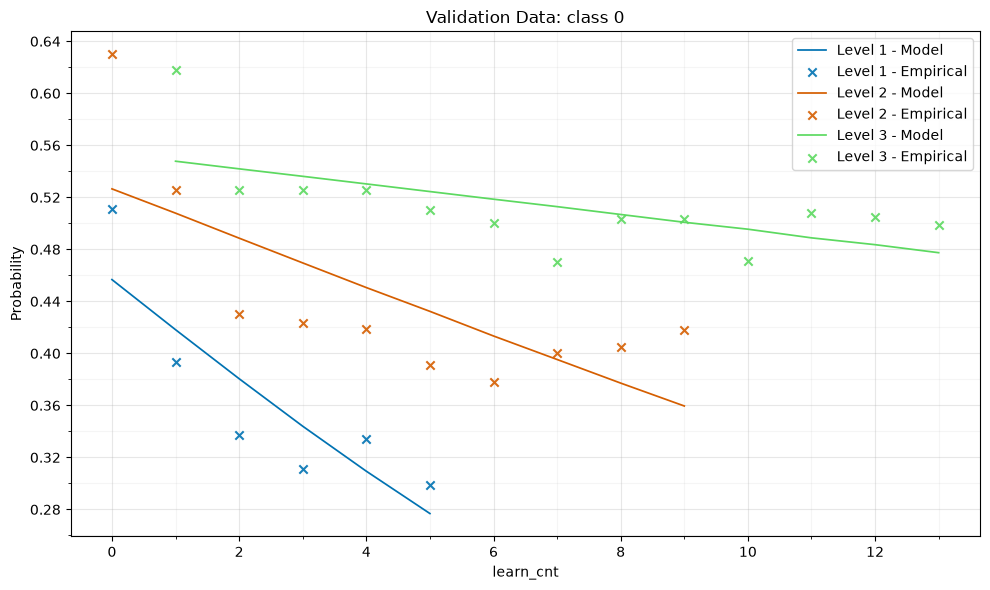

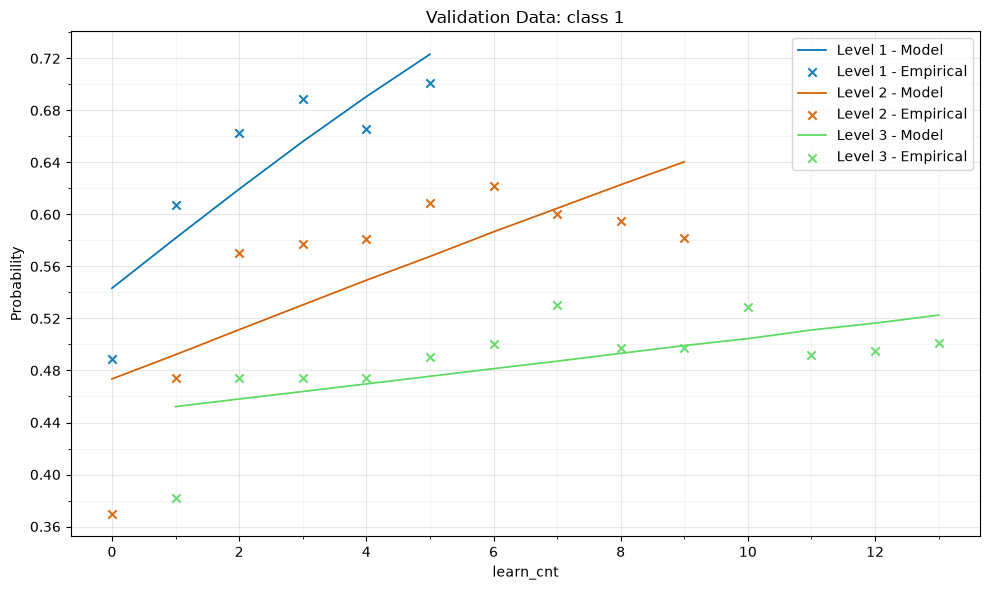

In [7]:
validation_data = tri_fold_out_of_fold.copy()

# One row per level_t / learn_cnt combination across the tri-fold out-of-fold predictions.
validation_combination_table = (
    validation_data
    .groupby(["level_t", "learn_cnt"], as_index=False)
    .agg(
        number_of_appearances=("a_t", "size"),
        empirical_success_rate=("a_t", "mean"),
        model_success_rate=("probability_class_1", "mean"),
    )
    .sort_values(["level_t", "learn_cnt"])
    .reset_index(drop=True)
)
display(validation_combination_table)

# ---------------------------------------------------------------------------
# Validation probability plots (tri-fold out-of-fold predictions)
# ---------------------------------------------------------------------------
levels = sorted(validation_data["level_t"].dropna().unique())
colours = {1: "#0072B2", 2: "#D55E00", 3: "#5CD960"}

class_columns = [
    (0, "probability_class_0", "Validation Data: class 0"),
    (1, "probability_class_1", "Validation Data: class 1"),
]

def plot_validation_class(class_value: int, probability_column: str, title: str) -> None:
    fig, axis = plt.subplots(figsize=(10, 6))
    for level in levels:
        level_frame = validation_data.loc[
            validation_data["level_t"] == level,
            ["learn_cnt", probability_column, "a_t"]
        ]
        if level_frame.empty:
            continue

        # Model line: mean predicted probability per learn_cnt, no point markers.
        model_frame = (
            level_frame
            .groupby("learn_cnt", as_index=False)[probability_column]
            .mean()
            .sort_values("learn_cnt")
        )

        # Empirical crosses: observed rate of the target class per learn_cnt.
        empirical_frame = (
            level_frame
            .assign(is_class=(level_frame["a_t"] == class_value).astype(float))
            .groupby("learn_cnt", as_index=False)["is_class"]
            .mean()
            .sort_values("learn_cnt")
        )

        plot_colour = colours.get(level)
        line_kwargs = {
            "linestyle": "-",
            "linewidth": 1.25,
            "zorder": 2,
            "label": f"Level {level} - Model",
        }
        scatter_kwargs = {
            "marker": "x",
            "s": 36,
            "alpha": 0.9,
            "zorder": 3,
            "label": f"Level {level} - Empirical",
        }

        if plot_colour is not None:
            line_kwargs["color"] = plot_colour
            scatter_kwargs["color"] = plot_colour

        axis.plot(model_frame["learn_cnt"], model_frame[probability_column], **line_kwargs)
        axis.scatter(empirical_frame["learn_cnt"], empirical_frame["is_class"], **scatter_kwargs)

    axis.set_xlabel("learn_cnt")
    axis.set_ylabel("Probability")
    axis.set_title(title)
    axis.xaxis.set_major_locator(MaxNLocator(nbins=12, integer=True))
    axis.xaxis.set_minor_locator(AutoMinorLocator(2))
    axis.yaxis.set_major_locator(MaxNLocator(nbins=10))
    axis.yaxis.set_minor_locator(AutoMinorLocator(2))
    axis.grid(True, which="major", alpha=0.3)
    axis.grid(True, which="minor", alpha=0.12)
    axis.legend()
    plt.tight_layout()
    plt.show()

for class_value, probability_column, title in class_columns:
    plot_validation_class(class_value, probability_column, title)
    

## 7. Manual Prediction

Use this section to test a single row manually.

In [8]:
example_dataset = CAPPED_DATASET_NAME
model = training_results[example_dataset]["model"]

custom_input = pd.DataFrame([{
    "level_t": 2,
    "learn_cnt": 7,
    # "a_t_minus_5": 0,
    # "a_t_minus_4": 0,
    # "a_t_minus_3": 0,
    # "a_t_minus_2": 0,
    # "a_t_minus_1": 0,
}])

print(f"Prediction for dataset: {example_dataset}")
display(custom_input)
print(f"Predicted class: {model.predict(custom_input)[0]}")
print(f"Predicted probability of class 1: {model.predict_proba(custom_input)[0, 1]:.4f}")


Prediction for dataset: obs100000LP_capped1000


,level_t,learn_cnt
0,2,7


Predicted class: 1
Predicted probability of class 1: 0.6082


## 8. How to Extend the Notebook

To add the lag columns later, change `USE_LAG_FEATURES` to `True`. That will include `a_t_minus_5` to `a_t_minus_1` in the model and in the capped dataset validation workflow.
